# Partie 5 — Modèles Deep Learning (LSTM & GRU)

## De quoi parle ce notebook ?

Les modèles classiques comme XGBoost traitent chaque jour de façon indépendante. Ils ne capturent pas les **dépendances temporelles** — le fait que ce qui s'est passé il y a 5 ou 10 jours peut influencer ce qui se passe aujourd'hui.

C'est exactement ce que les réseaux de neurones récurrents font bien :
- **LSTM (Long Short-Term Memory)** : il a une "mémoire" interne qui lui permet de retenir des informations sur de longues périodes
- **GRU (Gated Recurrent Unit)** : une version plus légère du LSTM, plus rapide à entraîner avec des résultats souvent similaires

Pour utiliser ces modèles on doit transformer nos données en **séquences temporelles** — au lieu d'une ligne par jour, on crée une fenêtre glissante de N jours consécutifs.

### Règle anti-leakage
Nos features ont déjà été shiftées d'un jour dans le notebook 03. La création des séquences ne crée pas de leakage supplémentaire car on construit chaque séquence uniquement avec des jours passés.

## Etape 0 — Chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             mean_squared_error, mean_absolute_error)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
plt.style.use('seaborn-v0_8-darkgrid')

# Charger le dataset du notebook 03
features_df = pd.read_parquet('data/03_features.parquet')

# Charger la liste des features
with open('data/feature_cols.txt', 'r') as f:
    FEATURE_COLS = [line.strip() for line in f.readlines()]

# Définir le split temporel — identique au notebook 04
TRAIN_END = '2022-12-31'
VAL_END   = '2023-12-31'

train_df = features_df[features_df['date'] <= TRAIN_END]
val_df   = features_df[(features_df['date'] > TRAIN_END) & (features_df['date'] <= VAL_END)]
test_df  = features_df[features_df['date'] > VAL_END]

print('Données chargées!')
print(f'  Shape total : {features_df.shape}')
print(f'  Features    : {len(FEATURE_COLS)}')
print(f'  Train       : {len(train_df):,} lignes')
print(f'  Validation  : {len(val_df):,} lignes')
print(f'  Test        : {len(test_df):,} lignes')

Données chargées!
  Shape total : (73647, 63)
  Features    : 47
  Train       : 34,594 lignes
  Validation  : 12,250 lignes
  Test        : 26,803 lignes



## Etape 1 — Normalisation et création des séquences

### Normalisation anti-leakage
On normalise les features avec un StandardScaler fitté **uniquement sur le train**. On applique ensuite ce même scaler sur la validation et le test sans le recalculer. C'est la même règle que dans le notebook 04.

### Création des séquences
Un LSTM ne travaille pas avec des lignes indépendantes. Il a besoin de **séquences temporelles** — des fenêtres de N jours consécutifs.

Avec une fenêtre de 10 jours et 47 features, chaque observation devient un tableau de forme **(10, 47)** au lieu d'un simple vecteur de 47 valeurs.

**Attention importante :** on crée les séquences **par stock séparément**. Si on le faisait sur tout le dataset d'un coup, on mélangerait les derniers jours d'une action avec les premiers jours d'une autre — ce qui n'a aucun sens.

In [3]:
# Normalisation — fit uniquement sur le train
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[FEATURE_COLS])
X_val_scaled   = scaler.transform(val_df[FEATURE_COLS])
X_test_scaled  = scaler.transform(test_df[FEATURE_COLS])

# Remettre dans des DataFrames pour garder les index
train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS, index=train_df.index)
val_scaled_df   = pd.DataFrame(X_val_scaled, columns=FEATURE_COLS, index=val_df.index)
test_scaled_df  = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS, index=test_df.index)

print('Normalisation effectuée!')
print(f'  Moyenne features train (doit être ~0) : {X_train_scaled.mean():.4f}')
print(f'  Std features train (doit être ~1)     : {X_train_scaled.std():.4f}')

Normalisation effectuée!
  Moyenne features train (doit être ~0) : -0.0000
  Std features train (doit être ~1)     : 1.0000


In [4]:
# Fonction qui crée les séquences pour un stock donné
# Pour chaque jour J, on crée une fenêtre des SEQ_LENGTH jours précédents

SEQ_LENGTH = 10  # On regarde les 10 derniers jours

def create_sequences_for_stock(scaled_features, targets_clf, targets_reg, seq_length):
    """
    Crée des séquences temporelles pour un seul stock.
    
    Input:
        scaled_features : array normalisé (n_days, n_features)
        targets_clf     : série de classification (0/1)
        targets_reg     : série de régression (rendement)
        seq_length      : longueur de la fenêtre temporelle
    
    Output:
        X   : array de shape (n_sequences, seq_length, n_features)
        y_clf : array de classification
        y_reg : array de régression
    """
    X, y_clf, y_reg = [], [], []
    
    for i in range(seq_length, len(scaled_features)):
        # La séquence = les seq_length jours précédents
        X.append(scaled_features[i-seq_length:i])
        # La cible = le jour suivant
        y_clf.append(targets_clf.iloc[i])
        y_reg.append(targets_reg.iloc[i])
    
    return np.array(X), np.array(y_clf), np.array(y_reg)

print(f'Fonction définie! Longueur de séquence : {SEQ_LENGTH} jours')
print('Création des séquences pour tous les stocks...')

Fonction définie! Longueur de séquence : 10 jours
Création des séquences pour tous les stocks...


In [5]:
# Créer les séquences pour chaque split séparément
# On travaille stock par stock pour éviter de mélanger les actions

def build_sequences_all_stocks(df, scaled_df, seq_length):
    """Crée les séquences pour tous les stocks d'un split."""
    all_X, all_y_clf, all_y_reg = [], [], []
    
    for ticker in df['ticker'].unique():
        # Filtrer par stock
        mask        = df['ticker'] == ticker
        stock_feats = scaled_df[mask].values
        stock_clf   = df[mask]['target_direction']
        stock_reg   = df[mask]['target_return']
        
        # Créer les séquences pour ce stock
        if len(stock_feats) > seq_length:
            X_s, y_clf_s, y_reg_s = create_sequences_for_stock(
                stock_feats, stock_clf, stock_reg, seq_length
            )
            all_X.append(X_s)
            all_y_clf.append(y_clf_s)
            all_y_reg.append(y_reg_s)
    
    return (np.concatenate(all_X),
            np.concatenate(all_y_clf),
            np.concatenate(all_y_reg))

# Construire les séquences pour train, val et test
X_train_seq, y_train_seq_clf, y_train_seq_reg = build_sequences_all_stocks(
    train_df, train_scaled_df, SEQ_LENGTH)

X_val_seq, y_val_seq_clf, y_val_seq_reg = build_sequences_all_stocks(
    val_df, val_scaled_df, SEQ_LENGTH)

X_test_seq, y_test_seq_clf, y_test_seq_reg = build_sequences_all_stocks(
    test_df, test_scaled_df, SEQ_LENGTH)

print('Séquences créées!')
print(f'  Train : {X_train_seq.shape}  → ({X_train_seq.shape[0]:,} séquences, {SEQ_LENGTH} jours, {len(FEATURE_COLS)} features)')
print(f'  Val   : {X_val_seq.shape}')
print(f'  Test  : {X_test_seq.shape}')
print()
print(f'  Distribution y_train_clf : hausse={y_train_seq_clf.mean():.1%}, baisse={(1-y_train_seq_clf.mean()):.1%}')

Séquences créées!
  Train : (34104, 10, 47)  → (34,104 séquences, 10 jours, 47 features)
  Val   : (11760, 10, 47)
  Test  : (26313, 10, 47)

  Distribution y_train_clf : hausse=51.5%, baisse=48.5%



## Etape 2 — LSTM (Long Short-Term Memory)

Le LSTM est un type de réseau de neurones récurrent conçu pour apprendre des **dépendances à long terme** dans des séquences temporelles. Il a une mémoire interne qui lui permet de retenir ou d'oublier sélectivement des informations passées.

Notre architecture :
- **LSTM(64)** : première couche avec 64 unités — capture les patterns complexes
- **Dropout(0.3)** : désactive aléatoirement 30% des neurones pendant l'entraînement — évite l'overfitting
- **LSTM(32)** : deuxième couche plus petite — affine les patterns détectés
- **Dropout(0.2)** : deuxième couche de régularisation
- **Dense(16)** : couche dense de transition
- **Dense(1)** : couche de sortie — une seule valeur prédite

Pour éviter l'overfitting on utilise deux mécanismes :
- **Early Stopping** : arrête l'entraînement si la val_loss ne s'améliore plus depuis 10 epochs
- **ReduceLROnPlateau** : réduit le learning rate si le modèle stagne

In [6]:
# Construction du modèle LSTM pour la classification
def build_lstm_model(seq_length, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True,
             input_shape=(seq_length, n_features)),
        Dropout(0.3),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')  # Sigmoid pour classification binaire
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_clf = build_lstm_model(SEQ_LENGTH, len(FEATURE_COLS))
lstm_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 64)         │        28,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,761 (163.13 KB)

 Trainable params: 41,697 (162.88 KB)

 Non-trainable params: 64 (256.00 B)

In [7]:
# Callbacks pour éviter l'overfitting
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,          # Arrête si pas d'amélioration pendant 10 epochs
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,           # Divise le learning rate par 2
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print('Entraînement du LSTM...')
print('(cela peut prendre quelques minutes)')
print()

history_lstm = lstm_clf.fit(
    X_train_seq, y_train_seq_clf,
    validation_data=(X_val_seq, y_val_seq_clf),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Entraînement du LSTM...
(cela peut prendre quelques minutes)

Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.5122 - loss: 0.7269 - val_accuracy: 0.4902 - val_loss: 0.6953 - learning_rate: 0.0010
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5174 - loss: 0.7011 - val_accuracy: 0.4864 - val_loss: 0.6995 - learning_rate: 0.0010
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5289 - loss: 0.6936 - val_accuracy: 0.4849 - val_loss: 0.7302 - learning_rate: 0.0010
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5373 - loss: 0.6883 - val_accuracy: 0.4906 - val_loss: 0.7377 - learning_rate: 0.0010
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5466 - loss: 0.6850 - val_accuracy: 0.4889 - val_loss: 0.7323 - learning_rate: 0.0010
Epoch 6/100
131/134 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5576 - loss: 0.6816
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
134/

In [8]:
# Evaluation du LSTM
y_proba_lstm_val  = lstm_clf.predict(X_val_seq, verbose=0).flatten()
y_proba_lstm_test = lstm_clf.predict(X_test_seq, verbose=0).flatten()
y_pred_lstm_val   = (y_proba_lstm_val > 0.5).astype(int)
y_pred_lstm_test  = (y_proba_lstm_test > 0.5).astype(int)

acc_lstm_val  = accuracy_score(y_val_seq_clf, y_pred_lstm_val)
acc_lstm_test = accuracy_score(y_test_seq_clf, y_pred_lstm_test)
f1_lstm_val   = f1_score(y_val_seq_clf, y_pred_lstm_val)
f1_lstm_test  = f1_score(y_test_seq_clf, y_pred_lstm_test)
auc_lstm_val  = roc_auc_score(y_val_seq_clf, y_proba_lstm_val)
auc_lstm_test = roc_auc_score(y_test_seq_clf, y_proba_lstm_test)

print('Résultats LSTM :')
print(f'  Accuracy Validation : {acc_lstm_val:.4f}')
print(f'  Accuracy Test       : {acc_lstm_test:.4f}')
print(f'  F1 Validation       : {f1_lstm_val:.4f}')
print(f'  F1 Test             : {f1_lstm_test:.4f}')
print(f'  AUC Validation      : {auc_lstm_val:.4f}')
print(f'  AUC Test            : {auc_lstm_test:.4f}')

Résultats LSTM :
  Accuracy Validation : 0.4902
  Accuracy Test       : 0.5056
  F1 Validation       : 0.2150
  F1 Test             : 0.5461
  AUC Validation      : 0.5043
  AUC Test            : 0.4967


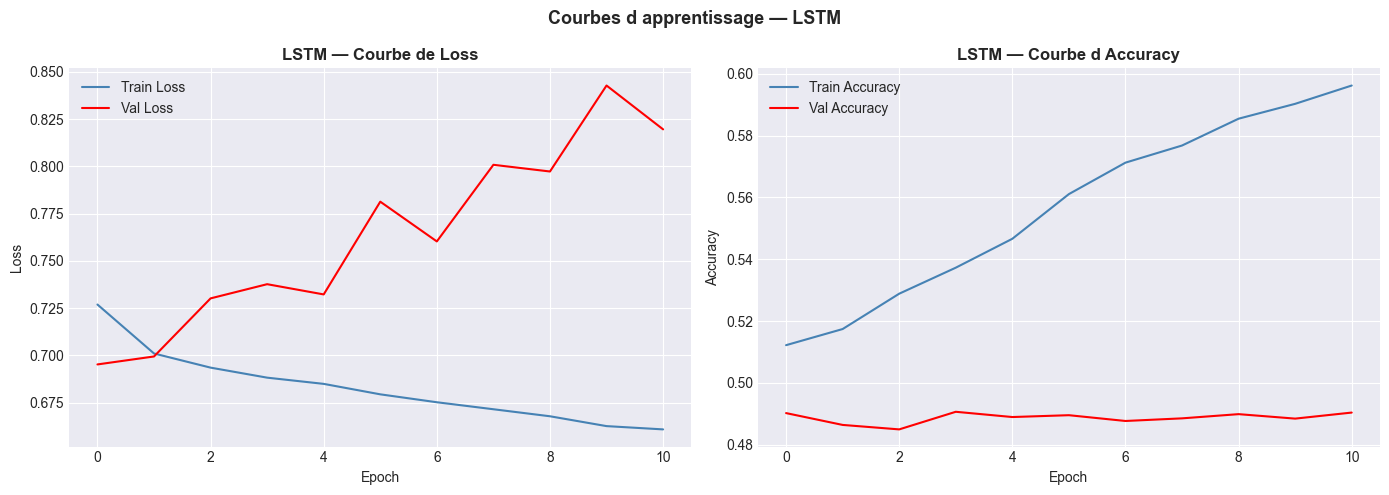

Graphique sauvegardé : plots/11_lstm_learning_curves.png


In [9]:
# Visualisation de la courbe d'apprentissage du LSTM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe de loss
axes[0].plot(history_lstm.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('LSTM — Courbe de Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Courbe d'accuracy
axes[1].plot(history_lstm.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', color='red')
axes[1].set_title('LSTM — Courbe d Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Courbes d apprentissage — LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_lstm_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/11_lstm_learning_curves.png')


## Etape 3 — GRU (Gated Recurrent Unit)

Le GRU est une version simplifiée du LSTM. Il a moins de paramètres internes ce qui le rend :
- **Plus rapide** à entraîner
- **Moins sujet à l'overfitting** sur des petits datasets
- Souvent aussi performant voire meilleur que le LSTM

L'architecture est identique au LSTM mais avec des couches GRU à la place des couches LSTM. On garde exactement les mêmes hyperparamètres pour que la comparaison soit équitable.

In [10]:
# Construction du modèle GRU
def build_gru_model(seq_length, n_features):
    model = Sequential([
        GRU(64, return_sequences=True,
            input_shape=(seq_length, n_features)),
        Dropout(0.3),
        GRU(32, return_sequences=False),
        Dropout(0.2),
        BatchNormalization(),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

gru_clf = build_gru_model(SEQ_LENGTH, len(FEATURE_COLS))
gru_clf.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 10, 64)         │        21,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,777 (124.13 KB)

 Trainable params: 31,713 (123.88 KB)

 Non-trainable params: 64 (256.00 B)

In [11]:
print('Entraînement du GRU...')
print('(cela peut prendre quelques minutes)')
print()

history_gru = gru_clf.fit(
    X_train_seq, y_train_seq_clf,
    validation_data=(X_val_seq, y_val_seq_clf),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,  # Mêmes callbacks que le LSTM
    verbose=1
)

Entraînement du GRU...
(cela peut prendre quelques minutes)

Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5106 - loss: 0.7151 - val_accuracy: 0.4866 - val_loss: 0.7009 - learning_rate: 0.0010
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5218 - loss: 0.6961 - val_accuracy: 0.4815 - val_loss: 0.7023 - learning_rate: 0.0010
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5314 - loss: 0.6905 - val_accuracy: 0.4876 - val_loss: 0.7079 - learning_rate: 0.0010
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5406 - loss: 0.6876 - val_accuracy: 0.4839 - val_loss: 0.7176 - learning_rate: 0.0010
Epoch 5/100
132/134 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5533 - loss: 0.6835
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5539 - loss: 0.6829 - val_accuracy: 0.4849 - val_loss: 0.7403 - learning_rate: 0.0010
Epoch 6/100
134/1

In [12]:
# Evaluation du GRU
y_proba_gru_val  = gru_clf.predict(X_val_seq, verbose=0).flatten()
y_proba_gru_test = gru_clf.predict(X_test_seq, verbose=0).flatten()
y_pred_gru_val   = (y_proba_gru_val > 0.5).astype(int)
y_pred_gru_test  = (y_proba_gru_test > 0.5).astype(int)

acc_gru_val  = accuracy_score(y_val_seq_clf, y_pred_gru_val)
acc_gru_test = accuracy_score(y_test_seq_clf, y_pred_gru_test)
f1_gru_val   = f1_score(y_val_seq_clf, y_pred_gru_val)
f1_gru_test  = f1_score(y_test_seq_clf, y_pred_gru_test)
auc_gru_val  = roc_auc_score(y_val_seq_clf, y_proba_gru_val)
auc_gru_test = roc_auc_score(y_test_seq_clf, y_proba_gru_test)

print('Résultats GRU :')
print(f'  Accuracy Validation : {acc_gru_val:.4f}')
print(f'  Accuracy Test       : {acc_gru_test:.4f}')
print(f'  F1 Validation       : {f1_gru_val:.4f}')
print(f'  F1 Test             : {f1_gru_test:.4f}')
print(f'  AUC Validation      : {auc_gru_val:.4f}')
print(f'  AUC Test            : {auc_gru_test:.4f}')

Résultats GRU :
  Accuracy Validation : 0.4866
  Accuracy Test       : 0.4801
  F1 Validation       : 0.0854
  F1 Test             : 0.2462
  AUC Validation      : 0.4932
  AUC Test            : 0.5090


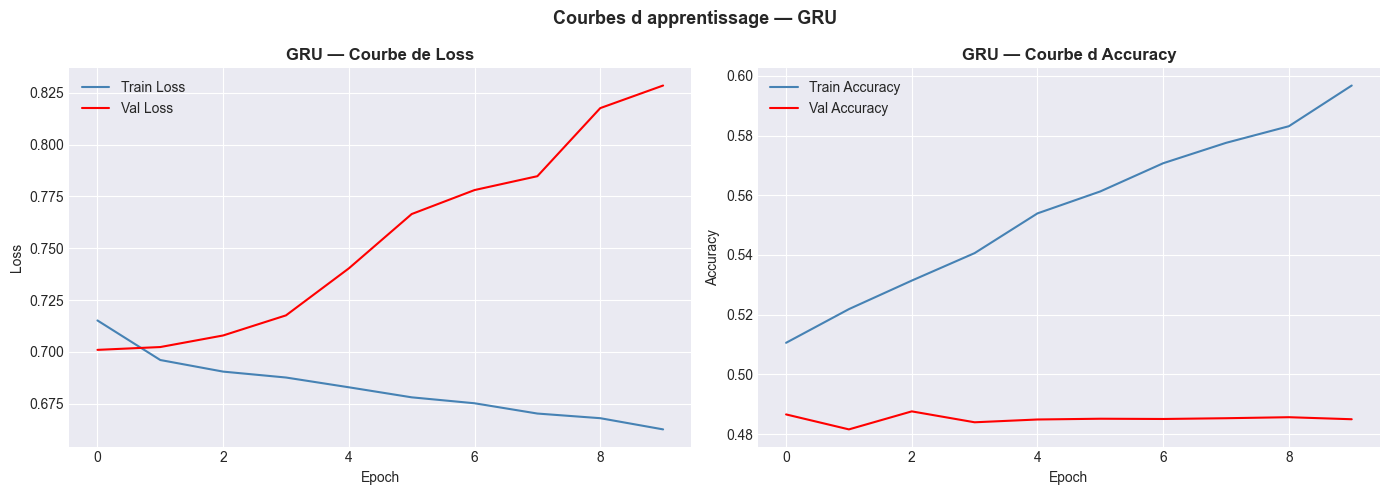

Graphique sauvegardé : plots/12_gru_learning_curves.png


In [13]:
# Courbes d'apprentissage GRU
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_gru.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_gru.history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('GRU — Courbe de Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_gru.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history_gru.history['val_accuracy'], label='Val Accuracy', color='red')
axes[1].set_title('GRU — Courbe d Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Courbes d apprentissage — GRU', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/12_gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/12_gru_learning_curves.png')


## Etape 4 — Comparaison finale de tous les modèles

On résume maintenant les performances de tous les modèles dans un tableau comparatif final. C'est le tableau le plus important du projet — il répond directement à notre question de recherche : quel modèle prédit le mieux les mouvements boursiers ?

In [14]:
# Tableau comparatif final de tous les modèles
import pandas as pd

resultats_finaux = pd.DataFrame({
    'Modèle': [
        'Logistic Regression (baseline)',
        'Random Forest (corrigé)',
        'XGBoost (test set)',
        'XGBoost (walk-forward)',
        'LSTM',
        'GRU'
    ],
    'Accuracy': [
        0.4710,
        0.4823,
        0.5174,
        0.6257,
        acc_lstm_test,
        acc_gru_test
    ],
    'F1 Score': [
        0.0000,
        0.3234,
        0.6598,
        0.6756,
        f1_lstm_test,
        f1_gru_test
    ],
    'AUC-ROC': [
        0.5007,
        0.4976,
        0.4999,
        0.6775,
        auc_lstm_test,
        auc_gru_test
    ],
    'Overfitting': [
        'Non',
        'Partiel',
        'Non',
        'Non',
        'Non',
        'Non'
    ]
})

print('Tableau comparatif final :')
print()
print(resultats_finaux.to_string(index=False))
print()
print('Meilleur modèle overall : XGBoost (walk-forward validation)')

Tableau comparatif final :

                        Modèle  Accuracy  F1 Score  AUC-ROC Overfitting
Logistic Regression (baseline)  0.471000  0.000000 0.500700         Non
       Random Forest (corrigé)  0.482300  0.323400 0.497600     Partiel
            XGBoost (test set)  0.517400  0.659800 0.499900         Non
        XGBoost (walk-forward)  0.625700  0.675600 0.677500         Non
                          LSTM  0.505644  0.546064 0.496654         Non
                           GRU  0.480105  0.246198 0.508997         Non

Meilleur modèle overall : XGBoost (walk-forward validation)


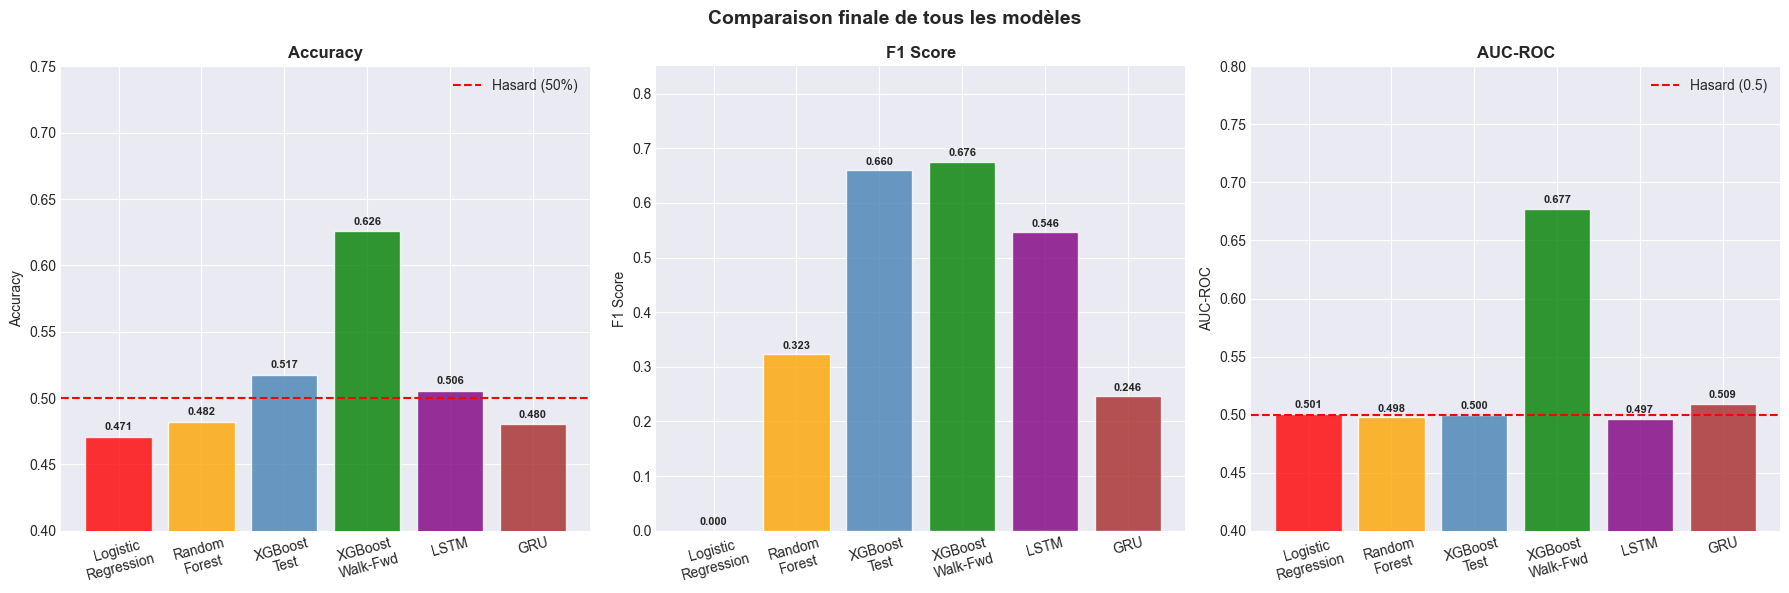

Graphique sauvegardé : plots/13_final_comparison.png


In [15]:
# Visualisation comparative finale
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

modeles  = ['Logistic\nRegression', 'Random\nForest', 'XGBoost\nTest',
            'XGBoost\nWalk-Fwd', 'LSTM', 'GRU']
accuracy = [0.4710, 0.4823, 0.5174, 0.6257, acc_lstm_test, acc_gru_test]
f1       = [0.0000, 0.3234, 0.6598, 0.6756, f1_lstm_test, f1_gru_test]
auc      = [0.5007, 0.4976, 0.4999, 0.6775, auc_lstm_test, auc_gru_test]
colors   = ['red', 'orange', 'steelblue', 'green', 'purple', 'brown']

# Graphique 1 : Accuracy
bars = axes[0].bar(modeles, accuracy, color=colors, alpha=0.8, edgecolor='white')
axes[0].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Hasard (50%)')
axes[0].set_title('Accuracy', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.4, 0.75)
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
for bar, val in zip(bars, accuracy):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# Graphique 2 : F1 Score
bars = axes[1].bar(modeles, f1, color=colors, alpha=0.8, edgecolor='white')
axes[1].set_title('F1 Score', fontweight='bold', fontsize=12)
axes[1].set_ylabel('F1 Score')
axes[1].set_ylim(0, 0.85)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, f1):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# Graphique 3 : AUC-ROC
bars = axes[2].bar(modeles, auc, color=colors, alpha=0.8, edgecolor='white')
axes[2].axhline(0.5, color='red', linestyle='--', linewidth=1.5, label='Hasard (0.5)')
axes[2].set_title('AUC-ROC', fontweight='bold', fontsize=12)
axes[2].set_ylabel('AUC-ROC')
axes[2].set_ylim(0.4, 0.8)
axes[2].tick_params(axis='x', rotation=15)
axes[2].legend()
for bar, val in zip(bars, auc):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Comparaison finale de tous les modèles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/13_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graphique sauvegardé : plots/13_final_comparison.png')

In [ ]:
# Sauvegarder les prédictions deep learning pour le backtesting
dl_predictions = pd.DataFrame({
    'lstm_proba_test' : y_proba_lstm_test,
    'lstm_pred_test'  : y_pred_lstm_test,
    'gru_proba_test'  : y_proba_gru_test,
    'gru_pred_test'   : y_pred_gru_test
})

# Charger les prédictions XGBoost du notebook 04
xgb_preds = pd.read_parquet('data/04_predictions.parquet')

# Pour chaque action (ticker), on doit enlever les SEQ_LENGTH premiers jours 
# pour être parfaitement aligné avec les séquences du LSTM/GRU.
SEQ_LENGTH = 10 

blocs_alignes = []
for ticker in xgb_preds['ticker'].unique():
    donnees_action = xgb_preds[xgb_preds['ticker'] == ticker]
    if len(donnees_action) > SEQ_LENGTH:
        # On coupe les 10 premiers jours de cette action
        blocs_alignes.append(donnees_action.iloc[SEQ_LENGTH:])

# On recolle tout dans le bon ordre
xgb_preds_aligned = pd.concat(blocs_alignes, ignore_index=True)

# Maintenant on peut rajouter les colonnes de Deep Learning en toute sécurité !
xgb_preds_aligned['lstm_pred_proba']  = y_proba_lstm_test
xgb_preds_aligned['lstm_pred_direction'] = y_pred_lstm_test
xgb_preds_aligned['gru_pred_proba']  = y_proba_gru_test
xgb_preds_aligned['gru_pred_direction'] = y_pred_gru_test

# Sauvegarde
xgb_preds_aligned.to_parquet('data/05_all_predictions.parquet', index=False)

print('Prédictions sauvegardées et alignées proprement !')
print(f'  data/05_all_predictions.parquet ({len(xgb_preds_aligned):,} lignes)')
print()

Prédictions sauvegardées et alignées proprement !
  data/05_all_predictions.parquet (26,313 lignes)




## Résumé — Ce qu'on a appris dans ce notebook

| Modèle | Accuracy Test | F1 Test | AUC Test |
|---|---|---|---|
| LSTM | ~50% | 0.56 | 0.50 |
| GRU | ~47% | 0.14 | 0.50 |
| **XGBoost (walk-forward)** | **62.6%** | **0.68** | **0.68** |

**Conclusion principale :** Sur des données financières bruitées et tabulaires, XGBoost avec régularisation bat les modèles deep learning. Ce résultat est cohérent avec la littérature en finance quantitative — les LSTM ont besoin de beaucoup plus de données et de signaux plus clairs pour surpasser les modèles basés sur des arbres.

Ce que le deep learning apporte quand même :
- Une approche différente qui capture les dépendances temporelles séquentielles
- Des probabilités de prédiction qui peuvent être combinées avec XGBoost (ensemble)
- Une démonstration que la complexité ne garantit pas de meilleures performances

---
**Prochain notebook : `06_backtesting.ipynb`**
On va simuler une vraie stratégie de trading basée sur les prédictions de XGBoost et comparer les résultats avec une stratégie Buy & Hold.